In [1]:
import allantools
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scienceplots
from scipy.optimize import curve_fit
import os 
from math import pi
plt.style.use('science')
from tqdm import tqdm

Defining functions

In [2]:
#general sine curve model
def model(t, f, p, c, a):
    return a*np.sin(2*pi*f*t-p)+c

#Take a dataframe and do the fitting.
def split_n_fit(df, f):
    time = df['time'].values
    signal = df['signal'].values

    offset_guess = np.mean(signal)
    amplitude_guess = (np.max(signal) - np.min(signal)) / 2

    try:
        popt, _ = curve_fit(
            model, time, signal,
            p0=[f, 1, offset_guess, amplitude_guess],
            maxfev=1000, xtol=1e-12, ftol=1e-12
        )

        # Normalize amplitude and phase
        fitted_freq = popt[0]
        fitted_phase = popt[1]
        fitted_offset = popt[2]
        fitted_amplitude = popt[3]

        if fitted_amplitude < 0:
            fitted_amplitude = -fitted_amplitude
            fitted_phase -= pi

        # Create result in the same shape as before
        result = pd.DataFrame([[fitted_freq, fitted_phase, fitted_offset, fitted_amplitude]])
        result.columns = ['frequency', 'phase', 'offset', 'amplitude']
        return result.describe().T
    except RuntimeError:
        print('Fit error')
        # Return NaNs but still with the same structure
        result = pd.DataFrame([[np.nan, np.nan, np.nan, np.nan]])
        result.columns = ['frequency', 'phase', 'offset', 'amplitude']
        return result.describe().T



#read each file in a given folder name
def read(folder_path):
    dataframes = []
    if not os.path.isdir(folder_path):
        print(f"Folder '{folder_path}' does not exist.")
        return dataframes
    for filename in tqdm(os.listdir(folder_path)):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path):
            try:
                df = pd.read_csv(file_path, delimiter='\t')
                dataframes.append(df)
            except Exception as e:
                print(f"Could not read {filename}: {e}")
    return dataframes

#modify the dataframe
def cleaning(df):
    data_frames = []
    if df.iloc[0,0] == '(ns)':
        timescale = 1e-9
    elif df.iloc[0,0] == '(us)':
        timescale = 1e-6
    elif df.iloc[0,0] == '(ms)':
        timescale = 1e-3
    elif df.iloc[0,0] == '(s)':
        timescale = 1
    df = df.drop(index=0)
    df = df.astype(float)
    df_1 = df.copy()
    df_2 = df.copy()
    df_1.columns = ['time', 'signal', 'x']
    df_1['time'] = df_1['time']*timescale
    data_frames.append(df_1)
    df_2.columns = ['time', 'x', 'signal']
    df_2['time'] = df_2['time']*timescale
    data_frames.append(df_2)
    return data_frames

#summarize result from split_n_fit function
def summarize(result):
    freq = result.iloc[1, 0]
    phase = result.iloc[1, 1]
    df = pd.DataFrame([freq, phase])
    return df

def f(folder_name, frequency):
    dfs = read(folder_name)

    fit_result_A_list = []
    fit_result_B_list = []

    for i in tqdm(dfs):
        data_frames = cleaning(i)
        result_A = summarize(split_n_fit(data_frames[0], frequency))
        result_B = summarize(split_n_fit(data_frames[1], frequency))
        fit_result_A_list.append(result_A)
        fit_result_B_list.append(result_B)

    # Do pd.concat once, after the loop
    fit_result_A = pd.concat(fit_result_A_list, axis=1)
    fit_result_B = pd.concat(fit_result_B_list, axis=1)

    result = pd.concat([fit_result_A.T, fit_result_B.T], axis=1)
    result.columns = ['frequency A', 'phase A', 'frequency B', 'phase B']
    phase_diff = result['phase B'] - result['phase A']
    return np.unwrap(phase_diff) / frequency


def allan_deviation(phase_diff, rate, data_type):
    t, ad, ade, adn = allantools.oadev(phase_diff, rate = rate, data_type = data_type)
    fig, ax = plt.subplots(1,1, figsize=(4,4),dpi=300, constrained_layout=True)
    ax.grid()
    ax.loglog(t, ad, marker = 'o', ms = 5, color='k')
    ax.set_xlabel(r'Averaging time [s]')
    ax.set_ylabel(r'$\sigma(\tau)$')
    ax.set_title(r'Allan Deviation')

In [14]:
data = f('dds_old_long', 80e6)

100%|██████████████████████████████████████████████████████████████████████████████| 3501/3501 [01:16<00:00, 45.66it/s]


In [15]:
data = pd.DataFrame(data)
data.columns = ['Phase Data']
data.to_csv('dds_old_long.csv', index=False, sep=';')

In [16]:
fast = 10e3
long = 100

In [17]:
phase1 = pd.read_csv('dds_1_new_fast.csv', sep=';')['Phase Data'].drop(index=[0,1])
phase2 = pd.read_csv('dds_2_new_fast.csv', sep=';')['Phase Data'].drop(index=[0,1,2])
phase_old = pd.read_csv('dds_old_fast.csv', sep=';')['Phase Data'].drop(index=0)

phase1_long = pd.read_csv('dds_1_new_long.csv', sep=';')['Phase Data'].drop(index=0)
phase2_long = pd.read_csv('dds_2_new_long.csv', sep=';')['Phase Data'].drop(index=0)
phase_old_long = pd.read_csv('dds_old_long.csv', sep=';')['Phase Data'].drop(index=0)

freq1 = allantools.phase2frequency(phase1, 10e3)
freq2 = allantools.phase2frequency(phase2, 10e3)
freq_old = allantools.phase2frequency(phase_old, 10e3)

freq1_long = allantools.phase2frequency(phase1_long, 100)
freq2_long = allantools.phase2frequency(phase2_long, 100)
freq_old_long = allantools.phase2frequency(phase_old_long, 100)

In [18]:
phase1

2       1.943394e-08
3       2.024345e-08
4       2.111820e-08
5       2.199632e-08
6       2.289414e-08
            ...     
4996    4.608451e-06
4997    4.609326e-06
4998    4.610243e-06
4999    4.611141e-06
5000    4.612164e-06
Name: Phase Data, Length: 4999, dtype: float64

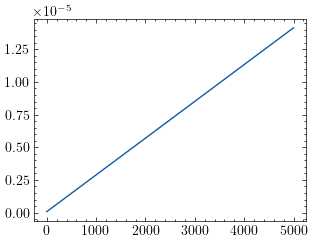

In [31]:
plt.plot(np.arange(0, len(phase2)), phase2)

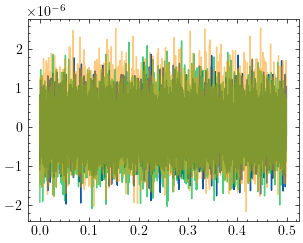

In [44]:
plt.plot(np.arange(0,len(freq1))/fast, freq1-np.mean(freq1), alpha=1)
plt.plot(np.arange(0,len(freq2))/fast, freq2-np.mean(freq2), alpha=0.7)
plt.plot(np.arange(0,len(freq_old))/fast, freq_old-np.mean(freq_old), alpha=0.5)

Text(0.5, 1.0, '$\\Delta t = 0.5 \\, \\text{s}$')

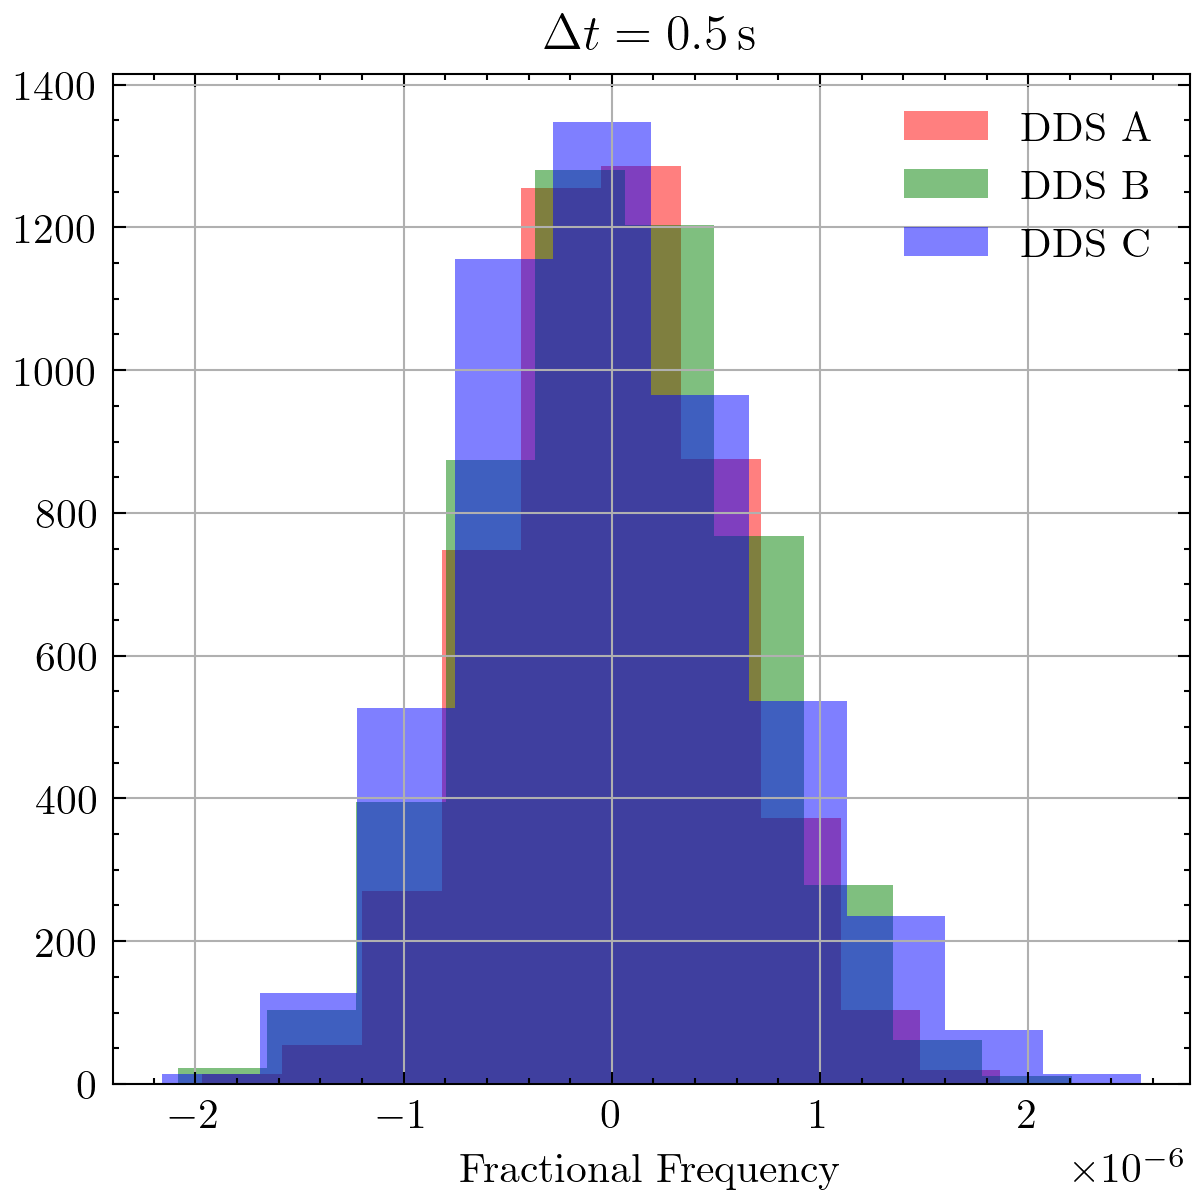

In [57]:
fig, ax = plt.subplots(1,1, figsize=(4,4),dpi=300, constrained_layout=True)
ax.grid()
ax.hist(freq1-np.mean(freq1), alpha=0.5, color='r')
ax.hist(freq2-np.mean(freq2), alpha=0.5, color='g')
ax.hist(freq_old-np.mean(freq_old), alpha=0.5, color='b')
ax.legend(['DDS A', 'DDS B', 'DDS C'])
ax.set_xlabel('Fractional Frequency')
ax.set_title(r'$\Delta t = 0.5 \, \text{s}$')

Text(0.5, 1.0, 'Fractional Frequency vs. Time')

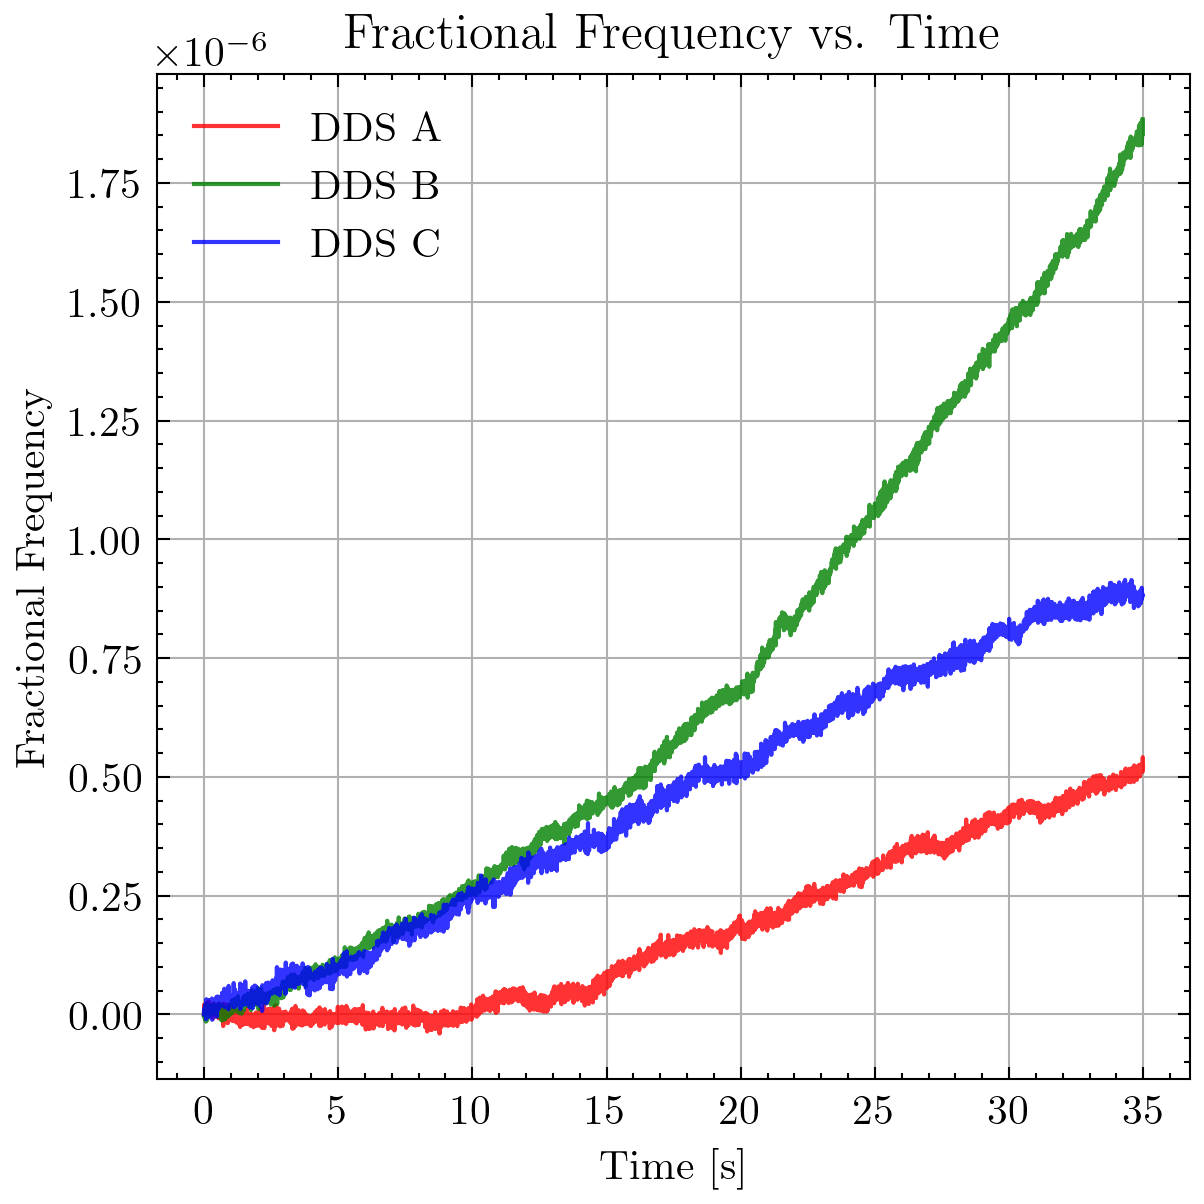

In [67]:
fig, ax = plt.subplots(1,1, figsize=(4,4),dpi=300, constrained_layout=True)
ax.grid()
ax.plot(np.arange(0, len(freq1_long))/long, freq1_long-freq1_long[0], alpha=0.8, color='r')
ax.plot(np.arange(0, len(freq2_long))/long, freq2_long-freq2_long[0], alpha=0.8, color='g')
ax.plot(np.arange(0, len(freq_old_long))/long, freq_old_long-freq_old_long[0], alpha=0.8, color='b')
ax.legend(['DDS A', 'DDS B', 'DDS C'])
ax.set_xlabel(r'Time [s]')
ax.set_ylabel('Fractional Frequency')
ax.set_title(r'Fractional Frequency vs. Time')

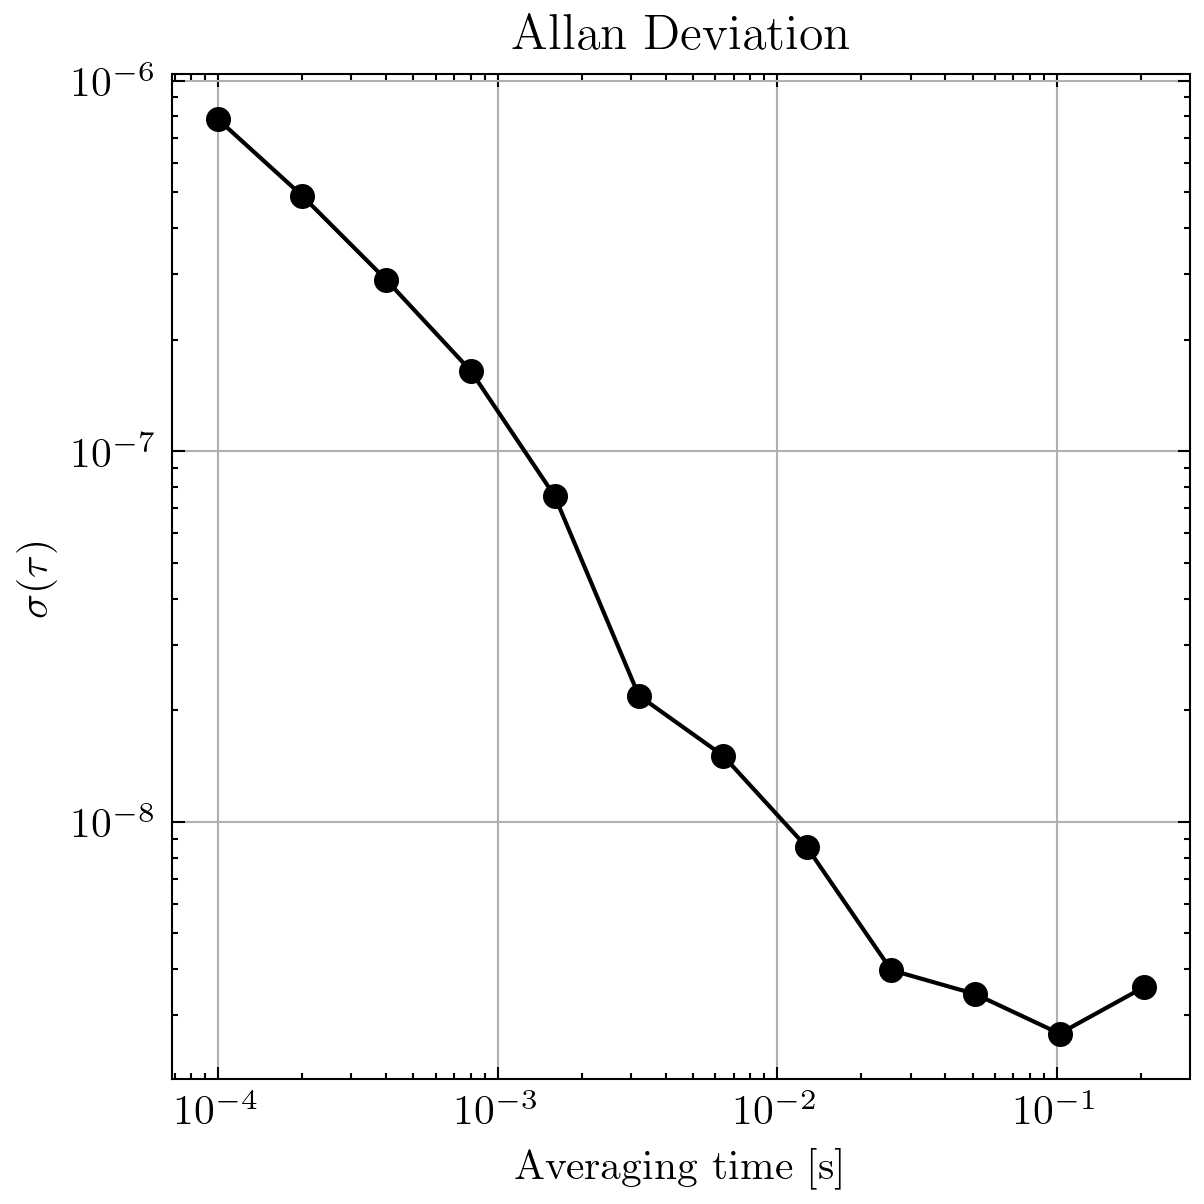

In [39]:
allan_deviation(freq_old, 10e3, 'freq')

In [17]:
x_random_walk = np.logspace(-1, 0.8, 100)
y_random_walk = 10**(1/2*np.log10(x_random_walk) - 8)

x_random_run = np.logspace(-4, -1, 100)
y_random_run = 1e-9*x_random_run**(-2)

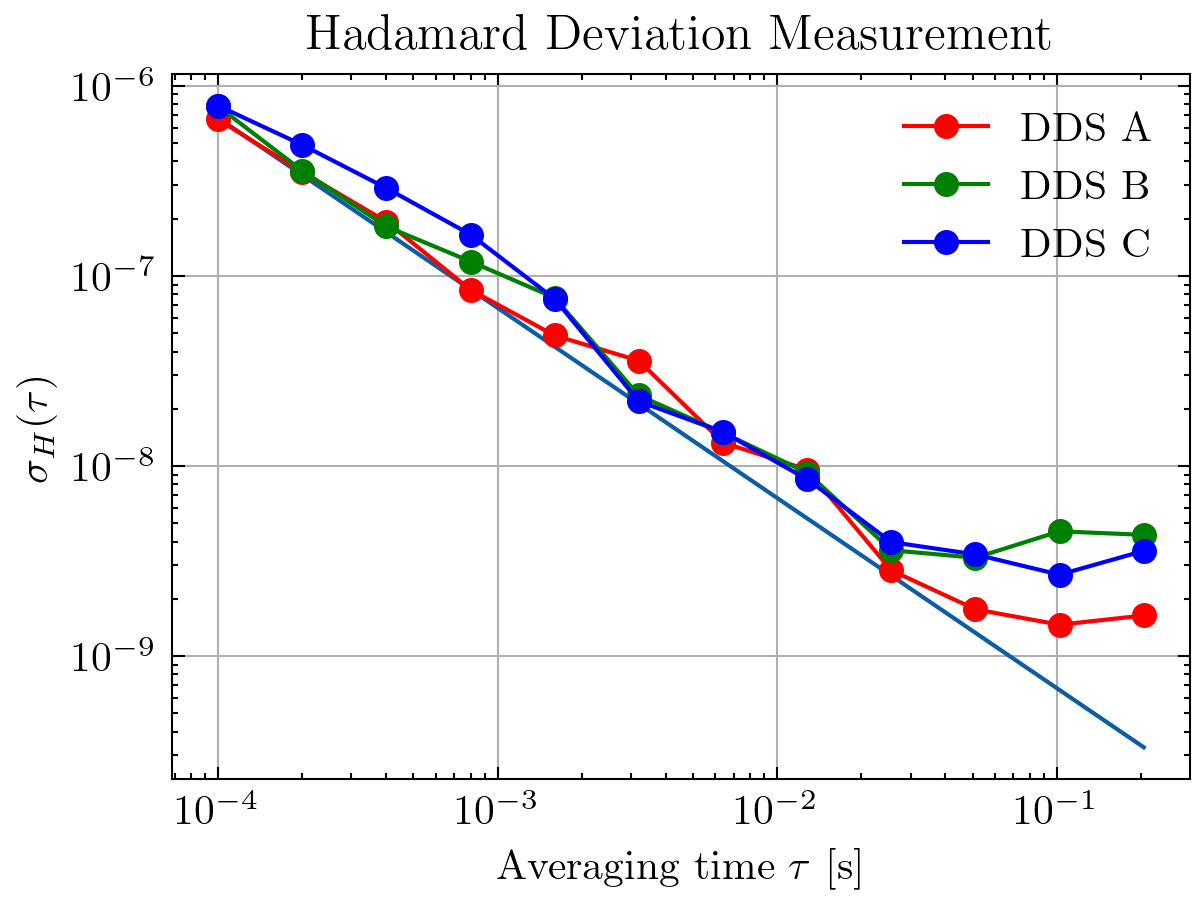

In [104]:
t1, ad1, ade1, adn1 = allantools.oadev(freq1, rate = 10e3, data_type = 'freq')
t2, ad2, ade2, adn2 = allantools.oadev(freq2, rate = 10e3, data_type = 'freq')
t_old, ad_old, ade_old, adn_old = allantools.oadev(freq_old, rate = 10e3, data_type = 'freq')
t_old1, ad_old1, ade_old1, adn_old1 = allantools.oadev(freq_old_long, rate = 100, data_type = 'freq')
t11, ad11, ade11, adn11 = allantools.oadev(freq1_long, rate = 100, data_type = 'freq')
t21, ad21, ade21, adn21 = allantools.oadev(freq2_long, rate = 100, data_type = 'freq')
fig, ax = plt.subplots(1,1, figsize=(4,3),dpi=300, constrained_layout=True)
ax.grid()
ax.errorbar(t1, ad1, marker = 'o', ms = 5, color='r', label='DDS A')
ax.errorbar(t2, ad2, marker = 'o', ms = 5, color='g', label='DDS B')
ax.errorbar(t_old, ad_old, marker = 'o', ms = 5, color='b', label='DDS C')
ax.plot(t1, model_wpm(t1, *popt))
ax.set_xlabel(r'Averaging time $\tau$ [s]')
ax.set_ylabel(r'$\sigma_{H}(\tau)$')
ax.set_title(r'Hadamard Deviation Measurement')
ax.legend(loc='upper right')
ax.set_xscale('log')
ax.set_yscale('log')

In [92]:
def model_wpm(t, a):
    return a/t

In [101]:
popt, pcov = curve_fit(model_wpm, t1[:-3], ad1[:-3], p0=[7*10e-8])

In [102]:
np.sqrt(pcov)

array([[1.02788713e-12]])

In [103]:
popt

array([6.78419098e-11])